In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.
# and David Edel
# This source code is licensed under the MIT license found in the
# LICENSE file in the root directory of this source tree.

"""Simple example of QAT using DDP (ResNet on CIFAR-10)
Adapted from https://github.com/akamaster/pytorch_resnet_cifar10"""
# os.environ["TORCH_LOGS"]="recompiles"
import torch
import torch._dynamo

torch._dynamo.config.cache_size_limit = 64
torch._dynamo.config.recompile_limit = 64
# torch._dynamo.config.verbose = True
# torch._inductor.config.debug = True

import json
import torch.nn as nn
from torchvision import transforms as T
from torch import optim

import itertools

from model import resnet
from model.resnet import ResNet,BasicBlock
import wandb
import time


from tqpmod.parq_utils import (
    NORM_LAYERS,
    get_param_groups,
    split_param_groups,
    create_data_loaders,
)
from tqpmod.tqp_optimizer_scale_train import TQPS
# from tqpmod.softbinning import SoftBinning # replace with custom
from tqpmod.logging_utils import init_loger_and_folder
from tqpmod.train_eval import train_epoch, evaluate

import math # for nan check

DEVICE = torch.device("cuda:0")
torch.set_float32_matmul_precision("high")  # improves matmul speed
import matplotlib.pyplot as plt


In [2]:
class SoftBinningScale:
    def __init__(self, bins=3):
        if bins < 3 or bins % 2 != 1:
            raise ValueError("bins must be odd >= 3")
        self.bins = bins // 2
        self.max = self.bins

    @torch.no_grad()
    @torch.compile()
    def call_test(self, x: torch.Tensor):
        x = torch.abs(x)
        y = 1 - self.max + x
        mask = x < self.max
        y[mask] = x[mask] - torch.floor(x[mask])
        y = y * torch.abs(1 - y)
        return y

    def compute_xright_quantile(self, x: torch.Tensor):
        x, _ = x.clone().detach().flatten().sort()
        third = x[x.shape[0] // 3]
        two_thirds = x[int(x.shape[0] * (2 / 3))]
        return third.abs() + two_thirds.abs()


soft_binning = SoftBinningScale(3)

In [3]:
@torch.compile()
@torch.no_grad()
def calc_reg_loss_scale_layer(
    optimizer:TQPS,
    soft_binning: SoftBinningScale,
    n_params,
    device=torch.device("cuda:0"),
    M=1,
    beta=5e-4,
    compute_per_layer_share_done = False
):
    """
    returns tuple of:
    avg_reg_loss, a norm, %done
    """

    reg_loss = torch.zeros((), device=device, requires_grad=False)
    quantized_params = torch.zeros(
        (), device=device, requires_grad=False, dtype=torch.int64
    )
    norm = torch.zeros((), device=device, requires_grad=False)
    per_layer_share_done = torch.zeros((len(optimizer.regularized_params)))
    for i, param in enumerate(optimizer.regularized_params):
        
        reg_loss += soft_binning.call_test(param).sum().detach()

        calc_param = param.detach()
        quantized_this_param = (
            (abs(calc_param - calc_param.round().clip(-M, M)) < (beta / 2))
            .sum()
            .to(torch.int64))
        quantized_params += quantized_this_param
        
        per_layer_share_done[i] = quantized_this_param / param.numel()
        norm += param.norm().detach()

    return (reg_loss / n_params).item(), norm.sqrt().item(), (quantized_params / n_params).item(), per_layer_share_done

In [4]:
@torch.no_grad()
def factor_function_test(params):
    return (params.flatten().std() * 2 * 0.5) * torch.ones((params.shape[0],),device=params.device)
    # the 0.5 and 2 cancel, but leave them in because we could adjust the params for this

(array([100., 100., 100., 100., 100., 100., 100., 100., 100., 100.]),
 array([-1.72945428, -1.3835634 , -1.03767252, -0.69178176, -0.34589088,
         0.        ,  0.34589076,  0.69178176,  1.03767252,  1.38356328,
         1.72945428]),
 <BarContainer object of 10 artists>)

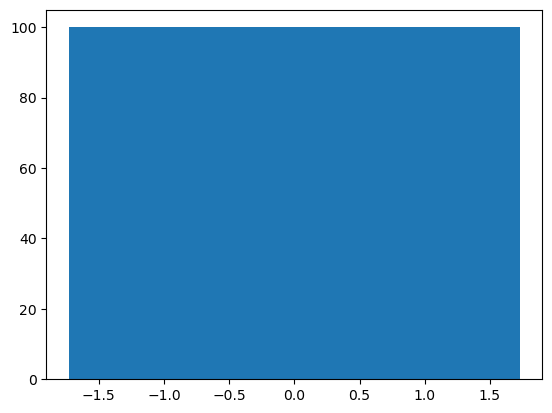

In [5]:
x = torch.linspace(-3.5,3.5,1000)
fac = factor_function_test(x)
plt.hist(x / fac)

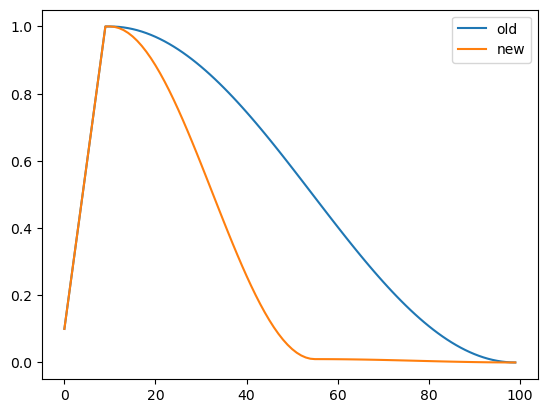

In [6]:
import numpy as np
num_epochs = 100
lr_warmup_epochs = 10
num_epochs_lr_schedule = 99
new_cos_epoch = 55
def get_lr_factor(epoch):
    if epoch < lr_warmup_epochs:
        return (epoch + 1) / lr_warmup_epochs
    elif epoch > num_epochs_lr_schedule:
        return get_lr_factor(num_epochs_lr_schedule)
    else:
        return max(
            [
                0.5
                * (
                    1
                    + np.cos(
                        np.pi
                        * (epoch - lr_warmup_epochs)
                        / (num_epochs_lr_schedule - lr_warmup_epochs)
                    )
                ) ,
                1e-9,
            ]
        )

percentage_new_cos = 0.01

def get_lr_factor_double_cos(epoch):
    if epoch < lr_warmup_epochs:
        return (epoch + 1) / lr_warmup_epochs
    elif epoch < new_cos_epoch:
        return max(
            [
                ( 0.5
                * (
                    1
                    + np.cos(
                        np.pi
                        * (epoch - lr_warmup_epochs)
                        / (new_cos_epoch - lr_warmup_epochs)
                    )
                ) ) * (1 - percentage_new_cos) + percentage_new_cos,
                1e-9,
            ]
        )
    else:
        return 0.5 * percentage_new_cos * (1 + np.cos(np.pi * (epoch-new_cos_epoch)/ (num_epochs - new_cos_epoch) ))
            
x = np.arange(100)
y = [get_lr_factor(xi) for xi in x]
y_new = [get_lr_factor_double_cos(xi) for xi in x]
plt.plot(x,y,label="old")
plt.plot(x,y_new,label="new")
plt.legend()

In [7]:

from typing import Callable

from tqpmod.model_utils import ScaleLayer
from tqpmod.tqp_optimizer import equisplit


@torch.no_grad()
def rebalance_layers_bn(
    model: nn.Module,
    param_dict: dict[nn.Parameter,dict],
    lr_schedule:torch.optim.lr_scheduler.LRScheduler,
    optimizer: torch.optim,
    dtype_target=torch.float32,
    dtype_calc=torch.float64,
    factor_function=equisplit,
    factor_function_args=(),
):
    for name, child in model.named_children():
        if isinstance(child,nn.Sequential) and (len(child) == 2) and isinstance(child[1],ScaleLayer):
            linear:nn.Linear | nn.Conv2d = child[0]
            scale:ScaleLayer = child[1]
            scale_shape = scale.scale.shape
           
            factors = factor_function(
                linear.weight.to(dtype_calc), *factor_function_args
            )
            factors = factors.reshape((-1, 1)).to(dtype_target)

            if isinstance(linear, nn.Conv2d):
                factors = factors.reshape((*factors.shape, 1, 1))

            linear.weight.copy_(
                (linear.weight.detach().to(dtype_calc) / factors).to(dtype_target)
            )
            param_dict[linear.weight]["group"]["lr"] = param_dict[linear.weight]["group"]["lr"] * ((1 / factors.mean()) ** 2).to(
                        dtype_target
                    ).item()
            index_weight = param_dict[linear.weight]["index"]
            lr_schedule.base_lrs[index_weight]=lr_schedule.base_lrs[index_weight] * ((1 / factors.mean()) ** 2).to(
                        dtype_target
                    )
            
            param_dict[linear.weight]["group"]["weight_decay"] = param_dict[linear.weight]["group"]["weight_decay"] * (factors.mean() ** 2).to(
                        dtype_target
                    ).item()
            optimizer.base_optimizer.state[linear.weight]["momentum_buffer"].div_(factors)

            if linear.bias is not None:
                if isinstance(linear, nn.Conv2d):
                    print("TODO: check if this bias is correct for conv2d bias")
                linear.bias.div_(factors.flatten())
                param_dict[linear.bias]["group"]["lr"] = param_dict[linear.bias]["group"]["lr"] * ((1 / factors.mean()) ** 2).to(
                        dtype_target
                    ).item()
                index_bias = param_dict[linear.bias]["index"]
                lr_schedule.base_lrs[index_bias]=lr_schedule.base_lrs[index_bias] * ((1 / factors.mean()) ** 2).to(
                        dtype_target
                    )
                optimizer.base_optimizer.state[linear.bias]["momentum_buffer"].div_(factors.flatten())

            scale.scale.mul_(factors.reshape(scale_shape))

            # BatchNorm scale:
            # stays the same

            # TODO: maybe also scale: scale lr.
        
        elif isinstance(child,nn.Conv2d):
            if "conv1" in name:
                bn = model.bn1                
            elif "conv2" in name:
                bn = model.bn2
            bn:nn.BatchNorm2d
            linear = child
            factors = factor_function(
                linear.weight.to(dtype_calc), *factor_function_args
            )
            factors = factors.reshape((-1, 1)).to(dtype_target)
            factors = factors.reshape((*factors.shape, 1, 1))
            linear.weight.copy_(
                (linear.weight.detach().to(dtype_calc) / factors).to(dtype_target)
            )
            param_dict[linear.weight]["group"]["lr"] = param_dict[linear.weight]["group"]["lr"] * ((1 / factors.mean()) ** 2).to(
                        dtype_target
                    ).item()
            index_weight = param_dict[linear.weight]["index"]
            lr_schedule.base_lrs[index_weight]=lr_schedule.base_lrs[index_weight] * ((1 / factors.mean()) ** 2).to(
                        dtype_target
                    )
            
            param_dict[linear.weight]["group"]["weight_decay"] = param_dict[linear.weight]["group"]["weight_decay"] * (factors.mean() ** 2).to(
                        dtype_target
                    ).item()
            optimizer.base_optimizer.state[linear.weight]["momentum_buffer"].div_(factors)

            bn.running_mean.mul_(1/factors.flatten())
            bn.running_var.mul_((1/ factors.flatten()) ** 2)

        else:
            rebalance_layers_bn(
                child,
                param_dict=param_dict,
                lr_schedule=lr_schedule,
                optimizer=optimizer,
                dtype_target=dtype_target,
                dtype_calc=dtype_calc,
                factor_function=factor_function,
                factor_function_args=factor_function_args,
            )


@torch.no_grad()
def inject_scale_layers_bn(
    model: nn.Module,
    param_dicts_list: list,
    dtype_target=torch.float32,
    dtype_calc=torch.float64,
    factor_function:Callable=equisplit,
    factor_function_args=(),
    learning_rate=0.1,
    weight_decay=0.02,
    scale_grad = True,
):
    for name, child in model.named_children():
        # Check for both Linear and Conv2d
        if isinstance(child, (nn.Linear, nn.Conv2d)):
            # Create a sequence: Original Layer -> Test Layer

            factors = factor_function(
                child.weight.to(dtype_calc), *factor_function_args
            )
            factors = factors.reshape((-1, 1))

            scale_shape = (1, child.weight.shape[0])

            if isinstance(child, nn.Conv2d):
                scale_shape = (*scale_shape, 1, 1)  # append 1,1 to shape for conv
                factors = factors.reshape((*factors.shape, 1, 1))

            child.weight.copy_(
                ((child.weight.detach().to(dtype_calc) / factors).to(dtype_target)).to(
                    dtype_target
                )
            )
            if child.bias is not None:
                if isinstance(child, nn.Conv2d):
                    print("TODO: check if this bias is correct for conv2d bias")
                child.bias.div_(factors.flatten())
                param_dicts_list.append(  # **2 for sgd
                {
                    "params": [child.bias],
                    "weight_decay": 0,
                    "lr": (learning_rate * ((1 / factors.mean()) ** 2)).to(
                        dtype_target
                    ),
                }
            )
            
            # Replace the attribute on the models Linear layers
            if isinstance(child,nn.Linear):
                scale = ScaleLayer(scale_shape).to(child.weight.device)
                scale.scale.requires_grad=scale_grad
                scale.scale.mul_(factors.to(dtype_target).reshape(scale_shape))
                new_block = nn.Sequential(child, scale)
                setattr(model, name, new_block)
            param_dicts_list.append(  # **2 for sgd
                {
                    "params": [child.weight],
                    "quant_bits": 0,
                    "weight_decay": (weight_decay * (factors.mean() ** 2)).to(dtype_target),
                    "lr": (learning_rate * ((1 / factors.mean()) ** 2)).to(
                        dtype_target
                    ),
                }
            )
            

        else:
            # Recurse for nested modules (like Bottlenecks in ResNet)

            inject_scale_layers_bn(
                child,
                param_dicts_list,
                dtype_target=dtype_target,
                dtype_calc=dtype_calc,
                factor_function=factor_function,
                factor_function_args=factor_function_args,
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                scale_grad=scale_grad
            )


In [8]:
# from tqpmod.model_utils import inject_scale_layers, rebalance_layers # reimplement



from typing import Any, Callable


def longrun_scale_layer(
    beta, train_params: dict[str, Any], run_name: str = "ScaleLayerTrain"
):
    try:
        logger, folder = init_loger_and_folder(run_name)
        history = {
            "train_loss": [],
            "train_acc": [],
            "test_loss": [],
            "test_acc": [],
            "reg_loss": [],
            "norm": [],
            "per_layer_share_done": [],
            "beta": [],
        }

        # ALL these hyperparams could get overwritten by train_params
        num_epochs = 600  # 1000  # like 310
        num_epochs_lr_schedule = 599  # 999 # 300
        learning_rate = 0.1
        weight_decay = 2e-4

        lr_warmup_epochs = 10
        percentage_new_cos = 0.1
        new_cos_epoch = (num_epochs - lr_warmup_epochs) / 2  # gets overwritten below

        REG_wait_epochs = 55  # 55

        SEED = torch.randint(0, 10000, (1,))
        batch_size = 64

        inject_scales = True

        if train_params is not None:
            num_epochs = train_params.get("num_epochs", num_epochs)
            num_epochs_lr_schedule = num_epochs - 1
            num_epochs_lr_schedule = train_params.get(
                "num_epochs_lr_schedule", num_epochs_lr_schedule
            )
            learning_rate = train_params.get("learning_rate", learning_rate)
            weight_decay = train_params.get("weight_decay", weight_decay)
            lr_warmup_epochs = train_params.get("lr_warmup_epochs", lr_warmup_epochs)
            percentage_new_cos = train_params.get(
                "percentage_new_cos", percentage_new_cos
            )
            new_cos_epoch = (
                num_epochs - lr_warmup_epochs
            ) / 2  # Overwrite default based on provided params
            new_cos_epoch = train_params.get("new_cos_epoch", new_cos_epoch)
            REG_wait_epochs = train_params.get("REG_wait_epochs", REG_wait_epochs)
            SEED = train_params.get("SEED", SEED)

            batch_size = train_params.get("batch_size", batch_size)

            inject_scales = train_params.get("inject_scales", inject_scales)

        torch.manual_seed(SEED)

        train_loader, val_loader = create_data_loaders(
            "~/data",
            batch_size,
            11,
            False,
            SEED,
        )
        steps_per_epoch = len(train_loader)

        # define loss function (criterion) and optimizer
        scaler = torch.amp.GradScaler("cuda")
        label_smoothing = 0.1
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing).to(DEVICE)  #
        model = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
        param_groups = []
        # TOD:
        rest_group = []
        names = {
            param: name for name, param in model.named_parameters()
        }  # for debugging

        if inject_scales:
            inject_scale_layers_bn(
                model,
                param_groups,
                factor_function=factor_function_test,
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                scale_grad=True,
            )
        else: # disables scale train
            param_groups.append(
                {
                    "params": [param for param in model.parameters() if len(param.shape) > 1],
                    "quant_bits": 32,
                    "weight_decay": weight_decay,
                    "learning_rate": learning_rate,
                }
            )

        model = model.to(DEVICE)
        # specify number of quantization bits for different parameter groups

        # None indicates that it will need to get updated before starting training
        # param_groups_quant = [{"params:":[param],"quant_bits":0,"weight_decay": None,learning_rate:None} for param in params_quant]
        param_groups_list = []
        for param_group in param_groups:
            param_groups_list.extend([id(param) for param in param_group["params"]])

        for name, param in model.named_parameters():
            if id(param) not in param_groups_list:
                rest_group.append(param)
        param_groups.append(
            {
                "params": rest_group,
                "weight_decay": 0,
                "lr": learning_rate,
            }  # use defalut lr
        )

        def build_lr_factor(lr_warmup_epochs, num_epochs_lr_schedule=None):
            num_epochs_lr_schedule = num_epochs_lr_schedule or (num_epochs - 1)

            def get_lr_factor(epoch):
                if epoch < lr_warmup_epochs:
                    return (epoch + 1) / lr_warmup_epochs
                elif epoch > num_epochs_lr_schedule:
                    return get_lr_factor(num_epochs_lr_schedule)
                else:
                    return max(
                        [
                            0.5
                            * (
                                1
                                + np.cos(
                                    np.pi
                                    * (epoch - lr_warmup_epochs)
                                    / (num_epochs_lr_schedule - lr_warmup_epochs)
                                )
                            ),
                            1e-9,
                        ]
                    )

            return get_lr_factor

        get_lr_factor: Callable = build_lr_factor(
            lr_warmup_epochs, num_epochs_lr_schedule
        )

        def build_lr_double_cos(
            lr_warmup_epochs, num_epochs_lr_schedule, new_cos_epoch, percentage_new_cos
        ):
            def get_lr_factor_double_cos(epoch):
                # test for quant
                if epoch < lr_warmup_epochs:
                    return (epoch + 1) / lr_warmup_epochs
                elif epoch < new_cos_epoch:
                    return max(
                        [
                            (
                                0.5
                                * (
                                    1
                                    + np.cos(
                                        np.pi
                                        * (epoch - lr_warmup_epochs)
                                        / (new_cos_epoch - lr_warmup_epochs)
                                    )
                                )
                            )
                            * (1 - percentage_new_cos)
                            + percentage_new_cos,
                            1e-9,
                        ]
                    )
                else:
                    return (
                        0.5
                        * percentage_new_cos
                        * (
                            1
                            + np.cos(
                                np.pi
                                * (epoch - new_cos_epoch)
                                / (num_epochs_lr_schedule - new_cos_epoch)
                            )
                        )
                    )

            return get_lr_factor_double_cos

        get_lr_factor_double_cos: Callable = build_lr_double_cos(
            lr_warmup_epochs, num_epochs_lr_schedule, new_cos_epoch, percentage_new_cos
        )

        base_optimizer = torch.optim.SGD(
            param_groups,
            learning_rate,
            momentum=0.9,
            weight_decay=weight_decay,
            fused=True,  # test
        )
        lr_scheduler = optim.lr_scheduler.LambdaLR(
            base_optimizer, lr_lambda=get_lr_factor
        )

        best_acc = 0.0
        best_reg_loss = float("inf")

        optimizer = TQPS(
            base_optimizer,
            len(train_loader),
            reg_wait_epochs=REG_wait_epochs,
            regularization_epochs=num_epochs,
            beta=beta,
            logger=logger,
        )
        optimizer.base_optimizer.zero_grad()

        n_reg_params = sum([torch.numel(x) for x in optimizer.regularized_params])
        model = torch.compile(model, mode="max-autotune", fullgraph=True, dynamic=False)
        torch.save(
            {
                "epoch": 0,
                "num_epochs": num_epochs,
                "SEED": SEED,
                "label_smoothing": label_smoothing,
                "REG_wait_epochs": REG_wait_epochs,
                "lr_warmup_epochs": lr_warmup_epochs,
                "num_epochs_lr_schedule": num_epochs_lr_schedule,
                "model_state_dict": model.state_dict(),
                "base_optimizer_state_dict": base_optimizer.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "current_acc": 0,
                "reg_loss": torch.inf,
                "lr_schedule": lr_scheduler.state_dict(),
                "scaler": scaler.state_dict(),
                "history": json.dumps(history),
                "best_reg_loss": best_reg_loss,
                "best_acc": best_acc,
                "batch_size": batch_size,
            },
            f"{folder}/init_pre_train.pth",
        )
        with wandb.init(
            project="ResNet-TQP",
            name=f"{run_name}-{beta}",
            config={
                "architecture": "ResNet20",
                "load_state": False,
                "Use Pretrained": f"{False}",
                "dataset": "CIFAR-10",
                "seed": SEED,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "optimizer": base_optimizer.__class__.__name__,
                "start_lr": learning_rate,
                "lr_warmup_epochs": lr_warmup_epochs,
                "weight_decay": weight_decay,
                "beta": beta,
                "reg_wait_epochs": REG_wait_epochs,
                "label_smoothing": label_smoothing,
                "note": "every epoch factor, dont wait",
            },
            # mode="disabled"
        ) as run:

            for epoch in range(0, num_epochs):
                # for epoch in range(start_epoch, 350):
                # for epoch in range(num_epochs, num_epochs+20):
                start_time = time.time()
                logger.info(
                    f"\nEpoch [{epoch+1}/{num_epochs}] | LR: {base_optimizer.param_groups[0]['lr']:.10f}"
                )

                if epoch == num_epochs - 1:
                    optimizer.set_final_beta()
                    logger.warning("DISABLED GRAD ON REG-PARAMS")
                    logger.info("overwrote beta to 1 for final epoch")

                # Train
                train_loss, train_acc = train_epoch(
                    model,
                    train_loader,
                    criterion,
                    optimizer,
                    scaler,
                    DEVICE,
                    epoch == 10,
                    epoch,
                    amp=True,
                )
                # TODO: compute change rate

                # keep REBALANCE_LAYERS and LR_SCHEDULER.STEP together, because we need to avoid training after rebalancing before updating learning rates
                if epoch == REG_wait_epochs - 1:  # TODO: check one off error
                    param_dict = {
                        group["params"][0]: {"index": index, "group": group}
                        for index, group in enumerate(optimizer.param_groups)
                        if len(group["params"]) == 1
                    }
                    # param_dict is needed because rebalance needs to know each parameter_groups index in the lr_schedulers base_lrs list.
                    # the group itself is also needed to adjust weight decay.
                    rebalance_layers_bn(
                        model,
                        param_dict,
                        lr_scheduler,
                        optimizer,
                        factor_function=factor_function_test,
                    )
                lr_scheduler.step()

                # TODO: think about wd decay with scaled again!!
                # for param_group in optimizer.get_regularized_param_groups():
                #     param_group["weight_decay"] = weight_decay * get_lr_factor(epoch)

                reg_loss, norm, share_done,per_layer_share_done = calc_reg_loss_scale_layer(
                    optimizer, soft_binning, n_reg_params, beta=beta
                )
                # decay beta based on finished_rate
                if epoch > 11 and optimizer.beta != 1.0:
                    new_beta = (1 - share_done) * beta + share_done * (beta * 1e-2)
                    new_beta = min(new_beta, history["beta"][-1])
                    if isinstance(optimizer.beta, torch.Tensor):
                        optimizer.beta.copy_(new_beta)
                    else:
                        optimizer.beta = torch.tensor(
                            new_beta, device=DEVICE, requires_grad=False
                        )
                else:
                    new_beta = beta
                # Save history
                history["beta"].append(new_beta)
                history["train_loss"].append(train_loss)
                history["train_acc"].append(train_acc)

                history["per_layer_share_done"].append(per_layer_share_done.detach().cpu().numpy().tolist())
                logger.info(
                    f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Reg Loss: {reg_loss:.4f}"
                )

                history["reg_loss"].append(reg_loss)
                history["norm"].append(norm)

                to_log = {
                    "lr": torch.tensor(lr_scheduler.get_last_lr()).mean().item(),
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "reg_loss": reg_loss,
                    "norm": norm,
                    "beta": optimizer.beta,
                    "share_done": share_done,
                }

                if epoch % 2 == 1:
                    test_loss, test_acc = evaluate(model, val_loader, criterion, DEVICE)
                    history["test_acc"].append(test_acc)
                    history["test_loss"].append(test_loss)
                    logger.info(
                        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%"
                    )
                    to_log.update(
                        {
                            "test_loss": test_loss,
                            "test_acc": test_acc,
                        }
                    )
                    best_acc = max([test_acc, best_acc])

                    # to_log.update({f"change_rate_layer_{i}": cr for i, cr in enumerate(change_rates)})

                    # Save best model
                    if reg_loss < best_reg_loss:
                        best_reg_loss = reg_loss
                        torch.save(
                            {
                                "epoch": epoch,
                                "num_epochs": num_epochs,
                                "SEED": SEED,
                                "label_smoothing": label_smoothing,
                                "REG_wait_epochs": REG_wait_epochs,
                                "lr_warmup_epochs": lr_warmup_epochs,
                                "num_epochs_lr_schedule": num_epochs_lr_schedule,
                                "model_state_dict": model.state_dict(),
                                "base_optimizer_state_dict": base_optimizer.state_dict(),
                                "optimizer_state_dict": optimizer.state_dict(),
                                "current_acc": test_acc,
                                "reg_loss": reg_loss,
                                "lr_schedule": lr_scheduler.state_dict(),
                                "scaler": scaler.state_dict(),
                                "history": json.dumps(history),
                                "best_reg_loss": best_reg_loss,
                                "best_acc": best_acc,
                                "batch_size": batch_size,
                            },
                            f"{folder}/best_reg_loss_model.pth",
                        )
                        logger.info(
                            f"✓ Saved best model with best reg_loss: {best_reg_loss:.3f}, accuracy: {test_acc:.2f}%"
                        )
                    else:
                        logger.info(
                            f"(X) model did not beat reg_loss: {reg_loss:.3f} vs {best_reg_loss:.3f}, accuracy: {test_acc:.2f}%"
                        )
                    # health check:
                    if math.isnan(reg_loss):
                        raise RuntimeError("idk why but reg loss in nan")
                epoch_time = time.time() - start_time
                logger.info(f"Epoch Time: {epoch_time:.2f}s")
                to_log.update({"epoch time:": epoch_time})
                run.log(to_log, step=epoch)
            # wandb context
            # if epoch == 10:
            #     break
    except Exception as e:
        logger.error(f"error: {e}")
    return history, model, optimizer

In [9]:
hist, model, optimizer = longrun_scale_layer(
    5e-4, {"num_epochs": 300, "REG_wait_epochs": 20}, "300_only_one_scale"
)

2026-06-08 16:54:39 [WARNING] Starting logging...
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/david/.netrc.
wandb: Currently logged in as: david-edel (david-edel-university-heidelberg-germany) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


2026-06-08 16:54:42 [INFO] 
Epoch [1/300] | LR: 0.7614812255
Training:   0%|          | 0/781 [00:00<?, ?it/s]/home/david/miniconda3/envs/newtorch/lib/python3.14/site-packages/torch/_inductor/select_algorithm.py:3458: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  current_size = base.storage().size()
Autotune Choices Stats:
{"num_choices": 13, "num_triton_choices": 11, "best_kernel": "triton_mm_119", "best_kernel_desc": "ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=64, BLOCK_M=32, BLOCK_N=16, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=2, num_warps=2", "best_time": 0.004095999989658594, "best_triton_pos": 0}
AUTOTUNE addmm(64x10, 64x64, 64x10)
strides: [0, 1], [64, 1], [1, 64]
dtypes: torch.float16, torch.float16, torch.float16
  trit

beta,███████████████████████████████▇▇▆▄▃▂▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█
epoch time:,█▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,▃██▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
norm,▆████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
reg_loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
share_done,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▄▅▆█
test_acc,▁▃▅▅▅▅▆▅▆▆▆▆▆▇▆▆▆▇▇▇▇▇▇▇▇▇██████████████
test_loss,█▄▆▅▅▄▄▄▅▄▃▅▄▄▃▃▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁
train_loss,█▆▆▆▆▆▅▆▅▅▅▅▅▅▅▅▅▅▅▅▄▄▄▄▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁
beta,1


In [26]:
model

OptimizedModule(
  (_orig_mod): ResNet(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
 

In [ ]:
share_done = hist["per_layer_share_done"]
shares_done = np.array(share_done)
print(shares_done.shape)
plt.plot(shares_done)
for i in range(shares_done.shape[1]):
    print(shares_done[-1,i])

In [ ]:
epochs = [{"num_epochs":100, "REG_wait_epochs":15}, {"num_epochs":200, "REG_wait_epochs":35}, {"num_epochs":500, "REG_wait_epochs":45}, {"num_epochs":2000, "REG_wait_epochs":80}]
for config in epochs:
    start_i = 0 if config["num_epochs"] != 100 else 4
    for i in range(start_i,5):
        hist, model,optimizer = longrun_scale_layer(5e-4,config,f"COMP_NoDoubleCos_{config["num_epochs"]}_{i}")

hist, model,optimizer = longrun_scale_layer(5e-4,{"num_epochs":8000, "REG_wait_epochs":100},f"COMP_NoDoubleCos_{8000}_{0}")

In [ ]:
for param in optimizer.param_groups[-1]["params"]:
    print(param.shape)

In [ ]:
hist, model,optimizer = longrun_scale_layer(5e-4,{},"long2k-reg")

In [ ]:
res = []
for i in range(5):
    res_once = {}
    for beta in [1e-2,5e-3,1e-3,5e-4,1e-4]:
        hist, model, optimizer = longrun_scale_layer(beta,"test_betDec_fix_momReb_test_lritem_no_betaschedule")
        res_once[beta]= hist
    res.append(res_once)

In [ ]:
betas = res[0].keys()
for beta in betas:
    accs = [res[i][beta]["test_acc"][-1] for i in range(len(res))]
    print(beta,accs,torch.tensor(accs).mean().item(),torch.tensor(accs).var().item())

print(beta,accs,torch.tensor(accs).mean().item(),torch.tensor(accs).var().item())

0.01 [90.33, 90.55, 90.15, 90.52, 90.53] 90.41600036621094 0.029979677870869637 

0.005 [91.03, 90.67, 90.71, 90.72, 90.32] 90.69000244140625 0.06354987621307373 

0.001 [91.74, 91.44, 91.7, 91.69, 91.86] 91.68599700927734 0.023479677736759186 

0.0005 [92.15, 91.92, 91.42, 91.87, 91.59] 91.78999328613281 0.0824509710073471 

0.0001 [91.57, 91.29, 91.52, 91.51, 91.58] 91.49400329589844 0.013929947279393673

In [ ]:
hist, model,optimizer = longrun_scale_layer(8e-4,"fixed-netadecay")

In [ ]:
train_loader, val_loader = create_data_loaders(
            "~/data",
            64,
            0,
            False,
            32,
            debug=False
        )
# param_dict = {group["params"][0]:group for group in optimizer.param_groups if len(group["params"])==1 }
criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)  #
print(evaluate(model._orig_mod,val_loader,criterion,DEVICE))
# rebalance_layers(model,param_dict,factor_function=factor_function_test)
print(evaluate(model,val_loader,criterion,DEVICE))

In [ ]:
dir(model.conv1)

In [ ]:
names = {param:name for name,param in model.named_parameters()}

In [ ]:
for param_group in optimizer.param_groups:
    name = [names[param_group["params"][i]] for i in range(len(param_group["params"]))]
    print(name,param_group.get("weight_decay",0),param_group.get("lr",0),param_group.get("weight_decay",0) * param_group.get("lr",0) )
    print()

In [ ]:
model.linear[1].scale.mean()

In [ ]:

plt.hist(model.conv1[0].weight.detach().cpu().flatten(),bins = 40)


In [ ]:
model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2.load_state_dict(model.state_dict())

In [ ]:
from tqdm import tqdm
def evaluate(model, loader, criterion, device,transform_train_x_dtype = torch.float32, amp=False):
    model.eval()
    running_loss = torch.zeros((), device=device, requires_grad=False)
    correct = torch.zeros((), device=device, requires_grad=False)
    total = 0

    pbar = tqdm(loader, desc="Evaluating")
    for images, labels in pbar:
        torch.compiler.cudagraph_mark_step_begin() # probably not needed
        images: torch.Tensor
        labels: torch.Tensor
        images, labels = images.to(device,transform_train_x_dtype, non_blocking=True), labels.to(
            device, non_blocking=True
        )
        with torch.amp.autocast("cuda",enabled=amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.detach()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().detach()
        total += labels.size(0)

    avg_loss = running_loss.item() / len(loader)
    test_accuracy = 100.0 * correct.item() / total
    return avg_loss, test_accuracy

In [ ]:
train_loader, val_loader = create_data_loaders(
            "~/data",
            128,
            11,
            False,
            32,
            debug=False
        )

In [ ]:
print("Testing: fp32_orig_mod ,fp32, fp32amp, bfp16")
criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)  #
model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
print(evaluate(model2._orig_mod,val_loader,criterion,DEVICE))
# rebalance_layers(model,param_dict,factor_function=factor_function_test)
print(evaluate(model2,val_loader,criterion,DEVICE))
print(evaluate(model2,val_loader,criterion,DEVICE,amp=True))
model2 = model2.to(torch.bfloat16)
print(evaluate(model2,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.bfloat16))


In [ ]:
print("Testing: fp32, fp32amp, fp16")
criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)  #
model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
print(evaluate(model2,val_loader,criterion,DEVICE))
print(evaluate(model2,val_loader,criterion,DEVICE,amp=True))
model2 = model2.to(torch.float16)
print(evaluate(model2._orig_mod,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.float16))


In [ ]:
print("Testing: fp8_per_tensor_scale, fp8_per_row_scale")
from torchao.quantization import (
    Float8DynamicActivationFloat8WeightConfig,
    PerRow,
    PerTensor,
    quantize_,
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)  #
model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
quantize_(model2, Float8DynamicActivationFloat8WeightConfig(granularity=PerTensor()))

print(evaluate(model2,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.float16))

model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
quantize_(model2, Float8DynamicActivationFloat8WeightConfig(granularity=PerRow()))
print(evaluate(model2,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.float16))

In [ ]:
print("Testing: int8_weight_only, int4_weight_only, int2_weight_only")
from torchao.quantization import (
    Float8DynamicActivationFloat8WeightConfig,
    PerRow,
    PerTensor,
    quantize_,Int8WeightOnlyConfig,Int4WeightOnlyConfig,IntxWeightOnlyConfig
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)  #

model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
quantize_(model2, Int8WeightOnlyConfig())
print(evaluate(model2,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.float16))

model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
quantize_(model2, Int4WeightOnlyConfig())
print(evaluate(model2,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.float16))

model2 = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
inject_scale_layers(model2,[])
model2 = model2.to(DEVICE)
model2 = torch.compile(model2)
model2:ResNet
model2.load_state_dict(model.state_dict())
quant_config = IntxWeightOnlyConfig(weight_dtype=torch.int2)
quantize_(model2, quant_config)
print(evaluate(model2,val_loader,criterion,DEVICE,transform_train_x_dtype=torch.float16))